<a href="https://www.kaggle.com/code/dimasprayoga/analisis-retention-revenue-e-commerce-olist?scriptVersionId=337783917" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


# Analisis Retensi & Revenue E-Commerce Olist

## 1. Business Problem

Dari total customer yang pernah belanja di platform Olist, mayoritas ternyata 
hanya membeli satu kali dan tidak pernah kembali — padahal akuisisi customer 
baru jauh lebih mahal dibanding mempertahankan customer yang sudah ada. 
Marketing membutuhkan pemahaman: segmen customer dan produk mana yang paling 
berpotensi dipertahankan melalui strategi retensi, agar budget marketing tidak 
habis untuk akuisisi customer baru secara terus-menerus.

## 2. Business Questions

1. Seberapa besar skala masalah retensi customer di Olist, dan apakah pola ini 
   konsisten di sepanjang waktu?
2. Apakah kualitas pelayanan (waktu pengiriman & rating review) berkontribusi 
   terhadap rendahnya retensi customer?
3. Segmen customer atau kategori produk apa yang secara alami memiliki potensi 
   repeat purchase lebih tinggi, dan bisa dijadikan target strategi retensi?

## 3. Hipotesis

- H1: Rendahnya retensi bersifat struktural (merata di semua cohort), bukan 
  disebabkan periode/musim tertentu
- H2: Customer dengan pengalaman pengiriman buruk memiliki kemungkinan lebih 
  kecil untuk repeat purchase
- H3: Customer yang memberi rating review rendah cenderung tidak kembali belanja
- H4: Kategori produk tertentu memiliki repeat rate lebih tinggi dibanding 
  kategori lain
- H5: Lokasi geografis customer tidak berpengaruh signifikan terhadap retensi

## 4. Data Understanding

##  Load Data

In [2]:
path = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
order_reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')

print("orders:", orders.shape)
print("customers:", customers.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("order_reviews:", order_reviews.shape)

orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
products: (32951, 9)
order_reviews: (99224, 7)


In [3]:
orders.info()
print("\n---\n")
orders['order_status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

---



order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


## 5. Data Cleaning

In [9]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [10]:
# Cek duplikat order_id
print("Duplikat order_id:", orders['order_id'].duplicated().sum())

# Cek duplikat customer_unique_id di tabel customers
print("Duplikat customer_id:", customers['customer_id'].duplicated().sum())

# Cek missing value di kolom kunci yang bakal sering dipakai
print("\nMissing value cek:")
print("customer_unique_id:", customers['customer_unique_id'].isna().sum())
print("product_category_name:", products['product_category_name'].isna().sum())

Duplikat order_id: 0
Duplikat customer_id: 0

Missing value cek:
customer_unique_id: 0
product_category_name: 610


In [11]:
df_clean = orders[orders['order_status'] == 'delivered'].copy()
print("Sebelum filter:", orders.shape)
print("Setelah filter (delivered only):", df_clean.shape)

Sebelum filter: (99441, 8)
Setelah filter (delivered only): (96478, 8)


In [12]:
products['product_category_name'] = products['product_category_name'].fillna('unknown_category')

# Verifikasi tidak ada lagi missing value
products['product_category_name'].isna().sum()

np.int64(0)

### Data Cleaning - Merge Tabel

In [13]:
# 1. Hitung total revenue per order (karena 1 order bisa berisi banyak item)
order_revenue = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    n_items=('order_item_id', 'count')
).reset_index()

# 2. Gabungkan order_items + products (buat dapat kategori produk)
order_items_full = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

# 3. Gabungkan df_clean (orders yang sudah difilter) + customers
df_clean = df_clean.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id', how='left'
)

# 4. Gabungkan dengan revenue per order
df_clean = df_clean.merge(order_revenue, on='order_id', how='left')

# 5. Gabungkan dengan kategori produk (buat df_full — versi paling lengkap)
df_full = df_clean.merge(
    order_items_full[['order_id', 'product_category_name']],
    on='order_id', how='left'
)

print("df_clean shape:", df_clean.shape)
print("df_full shape:", df_full.shape)
df_full.head()

df_clean shape: (96478, 13)
df_full shape: (110197, 14)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,total_price,total_freight,n_items,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,29.99,8.72,1,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,118.70,22.76,1,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,159.90,19.22,1,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,45.00,27.20,1,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,19.90,8.72,1,papelaria


## 6. Exploratory Data Analysis

### Cohort Analysis

In [14]:
# 1. Tandai bulan pembelian tiap order, dan cari bulan pembelian pertama tiap customer
df_clean['order_month'] = df_clean['order_purchase_timestamp'].dt.to_period('M')

first_purchase = df_clean.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']

df_clean = df_clean.merge(first_purchase, on='customer_unique_id', how='left')

df_clean[['customer_unique_id', 'order_month', 'cohort_month']].head()

,customer_unique_id,order_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02


### Metrik 1 — One-Time Buyer Rate

In [15]:
purchase_count = df_clean.groupby('customer_unique_id')['order_id'].nunique().reset_index()
purchase_count.columns = ['customer_unique_id', 'total_orders']

one_time_buyers = (purchase_count['total_orders'] == 1).sum()
total_customers = purchase_count['customer_unique_id'].nunique()
pct_one_time = one_time_buyers / total_customers * 100

print(f"Total customer unik: {total_customers}")
print(f"Customer yang cuma beli 1x: {one_time_buyers}")
print(f"Persentase one-time buyer: {pct_one_time:.2f}%")

Total customer unik: 93358
Customer yang cuma beli 1x: 90557
Persentase one-time buyer: 97.00%


### Metrik 2 — Cohort Retention Table

In [16]:
df_clean['cohort_index'] = (df_clean['order_month'] - df_clean['cohort_month']).apply(lambda x: x.n)

cohort_data = df_clean.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

cohort_size = cohort_pivot.iloc[:, 0]
retention_table = cohort_pivot.divide(cohort_size, axis=0) * 100

retention_table.round(1)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN
2017-05,100.0,0.5,0.5,0.3,0.3,0.3,0.4,0.1,0.3,0.3,0.3,0.3,0.2,0.0,0.2,0.2,NaN,NaN,NaN,NaN
2017-06,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.2,0.2,NaN,NaN,NaN,NaN,NaN


### Metrik 3 — Segmentasi Kategori Produk

In [17]:
# Gabungkan kategori produk ke df_clean
order_items_full = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)
df_full = df_clean.merge(
    order_items_full[['order_id', 'product_category_name']],
    on='order_id', how='left'
)

# Hitung total order per customer (buat tandai repeat vs one-time)
customer_orders = df_full.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']
customer_orders['is_repeat'] = customer_orders['total_orders'] > 1

# Gabungkan info kategori & status repeat jadi 1 tabel
customer_info = df_full.merge(customer_orders, on='customer_unique_id', how='left')

# Repeat rate per kategori (difilter minimal 100 customer biar valid)
category_repeat = customer_info.groupby('product_category_name')['is_repeat'].agg(['mean', 'count'])
category_repeat.columns = ['repeat_rate', 'total_customers']
category_repeat['repeat_rate'] = category_repeat['repeat_rate'] * 100

category_repeat_filtered = category_repeat[category_repeat['total_customers'] >= 100]
category_repeat_filtered.sort_values('repeat_rate', ascending=False).head(10)

,repeat_rate,total_customers
product_category_name,,
eletrodomesticos,17.374005,754
fashion_bolsas_e_acessorios,12.644836,1985
bebidas,12.188366,361
moveis_quarto,11.650485,103
fashion_roupa_masculina,11.200000,125
cama_mesa_banho,9.796403,10953
moveis_decoracao,9.779412,8160
moveis_sala,9.696970,495
fashion_underwear_e_moda_praia,9.448819,127


### Metrik 3 — Segmentasi Lokasi/State

In [18]:
customers_state = customers[['customer_unique_id', 'customer_state']].drop_duplicates()
customer_orders_state = customer_orders.merge(customers_state, on='customer_unique_id', how='left')

state_summary = customer_orders_state.groupby('customer_state').agg(
    repeat_rate=('is_repeat', 'mean'),
    total_customers=('customer_unique_id', 'count')
)
state_summary['repeat_rate'] = state_summary['repeat_rate'] * 100
state_summary = state_summary[state_summary['total_customers'] >= 100]
state_summary.sort_values('repeat_rate', ascending=False)

,repeat_rate,total_customers
customer_state,,
RO,4.329004,231
MT,3.504673,856
RJ,3.306201,11917
GO,3.166227,1895
SP,3.141281,39156
RS,3.076625,5168
DF,3.021298,2019
PR,2.977563,4769
MG,2.972187,11002


### Nilai Transaksi Pertama (Repeat vs One-Time Buyer)

In [19]:
first_order_value = df_full.merge(customer_orders, on='customer_unique_id', how='left')
first_order_value = first_order_value[first_order_value['order_month'] == first_order_value['cohort_month']]

avg_first_value = first_order_value.groupby('is_repeat')['total_price'].mean()
print("Rata-rata nilai transaksi pertama:")
print(avg_first_value)

Rata-rata nilai transaksi pertama:
is_repeat
False    152.605890
True     148.615572
Name: total_price, dtype: float64


## 7. Visualization

### Heatmap Cohort Retention

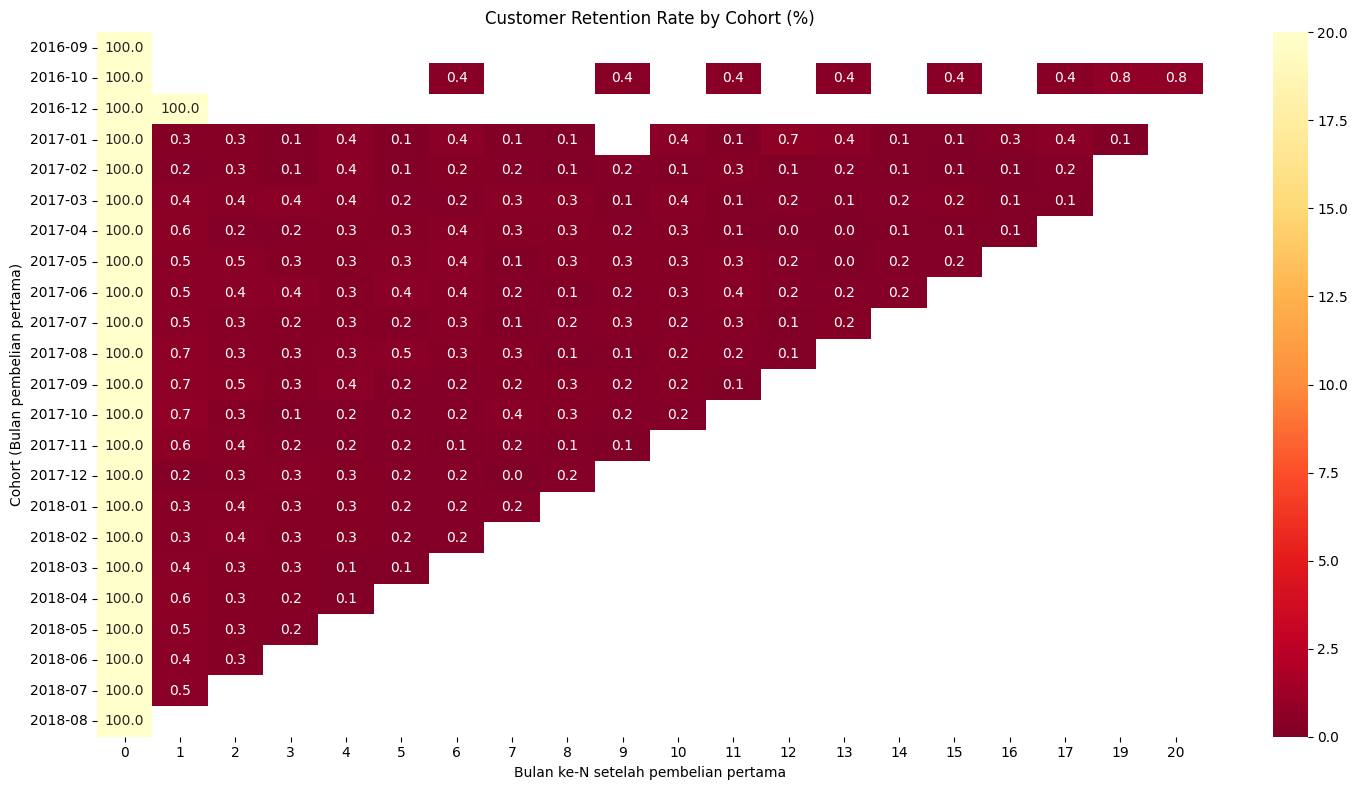

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(retention_table, annot=True, fmt='.1f', cmap='YlOrRd_r', vmin=0, vmax=20)
plt.title('Customer Retention Rate by Cohort (%)')
plt.xlabel('Bulan ke-N setelah pembelian pertama')
plt.ylabel('Cohort (Bulan pembelian pertama)')
plt.tight_layout()
plt.show()

### Bar Chart — Repeat Rate per Kategori Produk

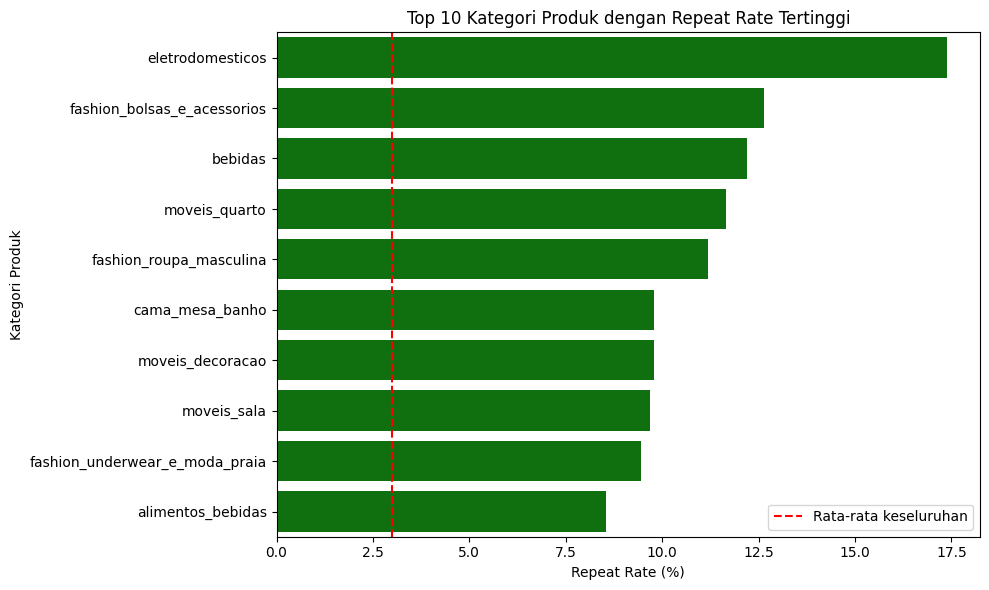

In [21]:
top10_category = category_repeat_filtered.sort_values('repeat_rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_category['repeat_rate'], y=top10_category.index, color='green')
plt.axvline(x=customer_orders['is_repeat'].mean() * 100, color='red', linestyle='--', label='Rata-rata keseluruhan')
plt.xlabel('Repeat Rate (%)')
plt.ylabel('Kategori Produk')
plt.title('Top 10 Kategori Produk dengan Repeat Rate Tertinggi')
plt.legend()
plt.tight_layout()
plt.show()

### Bar Chart — Repeat Rate per State

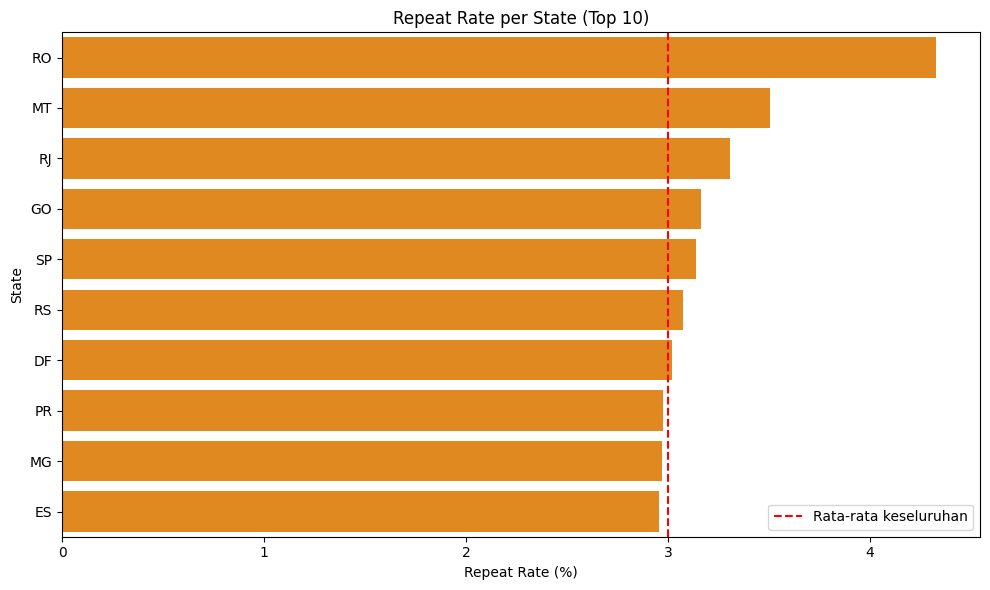

In [22]:
top10_state = state_summary.sort_values('repeat_rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_state['repeat_rate'], y=top10_state.index, color='darkorange')
plt.axvline(x=customer_orders['is_repeat'].mean() * 100, color='red', linestyle='--', label='Rata-rata keseluruhan')
plt.xlabel('Repeat Rate (%)')
plt.ylabel('State')
plt.title('Repeat Rate per State (Top 10)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Insight

### Insight 1 — Masalah Retensi Bersifat Struktural, Bukan Musiman

Dari ~93.000 customer unik, **97% hanya berbelanja satu kali** dan tidak pernah 
kembali. Retention rate bulanan secara konsisten berada **di bawah 1%** di 
seluruh cohort dari September 2016 hingga Agustus 2018 — tidak ada perbaikan 
tren dari waktu ke waktu maupun perbedaan signifikan antar periode.

**Artinya:** ini bukan masalah musiman atau cohort tertentu yang buruk, 
melainkan pola struktural yang terjadi di seluruh basis customer Olist. 
*(H1 terbukti)*

### Insight 2 — Kategori Produk adalah Sinyal Segmentasi Paling Kuat

Kategori produk `eletrodomesticos` (elektronik rumah tangga) memiliki repeat 
rate **17.4%** — hampir 6x lipat dari rata-rata keseluruhan (~3%). Kategori 
lain yang juga menonjol: `fashion_bolsas_e_acessorios` (12.6%) dan `bebidas` 
(12.2%). Bahkan kategori dengan volume customer besar seperti `cama_mesa_banho` 
(10.953 customer) tetap menunjukkan repeat rate 3x lipat dari rata-rata (9.8%).

**Artinya:** kategori produk rumah tangga & fashion tertentu secara alami 
mendorong pembelian ulang, jauh lebih kuat dibanding faktor lain yang diuji. 
*(H4 terbukti)*

### Insight 3 — Lokasi & Nilai Transaksi Bukan Faktor Penentu

Repeat rate antar state hanya berkisar **2.15% – 4.33%** — rentang yang sangat 
sempit. SP (São Paulo), dengan basis customer terbesar (39.156 orang), 
angkanya persis di rata-rata keseluruhan (3.14%). Begitu juga nilai transaksi 
pertama antara repeat buyer (Rp148.6) dan one-time buyer (Rp152.6) hampir 
tidak berbeda (~2.6%).

**Artinya:** baik lokasi geografis maupun besar-kecilnya nilai belanja pertama 
**tidak bisa dipakai** untuk memprediksi siapa yang akan repeat purchase. 
*(H5 terbukti; nilai transaksi juga terbukti tidak signifikan)*

## 9. Recommendation

### Rekomendasi 1 — Alihkan Sebagian Budget Akuisisi ke Program Retensi Bertarget

Dengan 97% customer hanya belanja sekali, strategi akuisisi customer baru saja 
tidak akan cukup untuk pertumbuhan jangka panjang — biayanya terus membengkak 
tanpa ada basis customer setia yang menopang. Marketing disarankan mulai 
mengalokasikan sebagian budget (bisa diuji coba dulu dalam skala kecil/A-B 
test) untuk program retensi yang **ditargetkan**, bukan disebar merata ke 
semua customer.

### Rekomendasi 2 — Fokuskan Program Retensi pada Kategori Produk Bernilai Tinggi

Kategori `eletrodomesticos`, `fashion_bolsas_e_acessorios`, dan `bebidas` 
terbukti memiliki repeat rate 4-6x lipat di atas rata-rata. Rekomendasi 
konkret:
- Kirim **email/notifikasi re-engagement** khusus ke customer yang transaksi 
  pertamanya di kategori-kategori ini (peluang balik lagi jauh lebih tinggi 
  dibanding customer kategori lain)
- Uji coba **cross-sell** produk dari kategori tinggi-repeat ini ke customer 
  yang baru sekali beli di kategori lain

### Rekomendasi 3 — Jangan Habiskan Budget untuk Personalisasi Berbasis Lokasi

Karena repeat rate antar state hampir seragam (2-4%), personalisasi program 
retensi berdasarkan lokasi geografis **kemungkinan besar tidak akan efektif** 
dan sebaiknya tidak menjadi prioritas alokasi sumber daya.

### Rekomendasi 4 — Investigasi Lanjutan pada Kualitas Pelayanan

Business Question #2 (soal pengiriman & review) belum sempat diuji secara 
mendalam dalam analisis ini — mengingat besarnya skala masalah retensi (97%), 
disarankan sebagai langkah investigasi lanjutan untuk memastikan bukan 
pengalaman pelayanan yang jadi penyebab utama.

## Limitations & Next Steps

- Analisis ini tidak mencakup perbandingan dengan kompetitor karena 
  keterbatasan data eksternal
- Hipotesis terkait kualitas pelayanan (H2, H3) belum diuji karena keterbatasan 
  waktu — rencana lanjutan: analisis tabel `order_reviews` dan keterlambatan 
  pengiriman
- Rentang data hanya 24 bulan, sehingga pola pembelian ulang dengan siklus 
  lebih dari 2 tahun (misal produk elektronik/furnitur yang awet) tidak dapat 
  teramati dalam dataset ini